# All Resource: https://github.com/mrdbourke/tensorflow-deep-learning/
# Documentation: https://www.tensorflow.org/learn

In [28]:
import tensorflow as tf
print(tf.__version__)
#the default is float32
#if Cuda gpu Tf auto use if possible
tf.config.list_physical_devices("GPU") #dont pass gpu to see all

2.19.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [29]:
scalar = tf.constant(9.); #constant is immutable
scalar
scalar.ndim

0

In [30]:
oneDvec = tf.constant([10., 10])
oneDvec.ndim
# 2d is a matrix

1

In [31]:
tensor = tf.constant([[[19,92], [13, 23]],
                         [[23, 23], [12, 14]],
                         [[134, 252], [132, 0]]], dtype=tf.float16)
tensor.ndim

3

In [32]:
# Variables
var = tf.Variable([10,012.]);
print(var);
var[1].assign(100)
print(var);

<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([10., 12.], dtype=float32)>
<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([ 10., 100.], dtype=float32)>


In [33]:
#Random Tensors
random1 = tf.random.Generator.from_seed(108)
random1, random2 = random1.normal(shape=(3,2)), random1.uniform(shape=(3,2), dtype=tf.float16)
print(random1, "\n\n", random2)

tf.Tensor(
[[-2.2454505 -0.7396203]
 [-0.2343236  0.8082244]
 [-1.2844347 -1.2784132]], shape=(3, 2), dtype=float32) 

 tf.Tensor(
[[0.3408  0.2754 ]
 [0.1729  0.0664 ]
 [0.2383  0.05762]], shape=(3, 2), dtype=float16)


In [34]:
#Shuffling the values of a tensor randomly
random1 = tf.constant([[10, 7],
                       [3, 4],
                       [2, 5]]);
tf.random.set_seed(42); #global seed
tf.random.shuffle(random1, seed=42); #operation-level seed
print(random1);

tf.Tensor(
[[10  7]
 [ 3  4]
 [ 2  5]], shape=(3, 2), dtype=int32)


In [35]:
print(tf.ones([5,7]), "\n") #similar to numpy.ones()
print(tf.zeros([5,7]))

tf.Tensor(
[[1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1.]], shape=(5, 7), dtype=float32) 

tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]], shape=(5, 7), dtype=float32)


In [36]:
import numpy as np
arr = np.arange(1, 25, dtype=np.int32)
tens = tf.constant(arr, shape=(2, 3, 4)) ## if dims diff newdims == total elements
tens, tens.shape #ndims !work

(<tf.Tensor: shape=(2, 3, 4), dtype=int32, numpy=
 array([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],
 
        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]], dtype=int32)>,
 TensorShape([2, 3, 4]))

In [37]:
# Attributes
# Shape, Rank, Axis/Dims, Size
tens.dtype, tens.shape, #tens.rank == tens.ndims, tens.size
#tens[:2, :2, :2, :2]
# rank3_tens = tens(..., tf.newAxis)
# tf.expand_dims(rank2_tens, axis=-1)

(tf.int32, TensorShape([2, 3, 4]))

In [38]:
#Manipulation/ Operation on a tensor
tensor = tf.constant([[10,7], [3,4]])
#tensor+10, tensor*10, tensor-10, tensor/10 , tensor*tensor #tf.math.(func)
tf.multiply(tensor, 10), tf.add(tensor, 10), tf.subtract(tensor, 10), tf.divide(tensor, 10)

(<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
 array([[100,  70],
        [ 30,  40]], dtype=int32)>,
 <tf.Tensor: shape=(2, 2), dtype=int32, numpy=
 array([[20, 17],
        [13, 14]], dtype=int32)>,
 <tf.Tensor: shape=(2, 2), dtype=int32, numpy=
 array([[ 0, -3],
        [-7, -6]], dtype=int32)>,
 <tf.Tensor: shape=(2, 2), dtype=float64, numpy=
 array([[1. , 0.7],
        [0.3, 0.4]])>)

In [39]:
#MatMul == dot product
tf.linalg.matmul(tensor, tensor) #tf.matmul(tensor, tensor)
tensor @ tensor #like np
tf.tensordot(tensor, tensor, axes = 1) #same

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>

In [40]:
#tf.reshape(Y, shape=(2,3))
#tf.transpose(Y) #preffered if dims don't align

In [41]:
#Changing DataType of tensors
B = tf.constant(np.random.randint(0, 100, size=10))
B = tf.cast(B, dtype=tf.float16) #float16 make oprs faster
B

<tf.Tensor: shape=(10,), dtype=float16, numpy=array([10., 54., 29., 23., 29., 79., 31.,  1., 46., 61.], dtype=float16)>

In [42]:
#Aggregation: Min, Max, Mean/Avg, Sum, Abs
B = tf.constant(np.random.randint(-100, 100, size=10))
tf.abs(B), tf.reduce_min(B), tf.reduce_max(B), tf.reduce_mean(B), tf.reduce_sum(B)

(<tf.Tensor: shape=(10,), dtype=int64, numpy=array([39, 99, 86, 19, 17, 70, 55,  6, 85, 45])>,
 <tf.Tensor: shape=(), dtype=int64, numpy=-85>,
 <tf.Tensor: shape=(), dtype=int64, numpy=99>,
 <tf.Tensor: shape=(), dtype=int64, numpy=11>,
 <tf.Tensor: shape=(), dtype=int64, numpy=117>)

In [43]:
#Variance etc. of a tensor
import tensorflow_probability as tfp
tfp.stats.variance(B), tf.math.reduce_std(tf.cast(B, dtype=tf.float32))

(<tf.Tensor: shape=(), dtype=int64, numpy=3521>,
 <tf.Tensor: shape=(), dtype=float32, numpy=59.33810043334961>)

In [44]:
#Finding Positional Min/Max i.e. for a row/col
C = tf.constant(tf.random.uniform(shape=[5,10,1]))
tf.argmin(C, axis=1), tf.argmax(C, axis=1) #for each row

(<tf.Tensor: shape=(5, 1), dtype=int64, numpy=
 array([[4],
        [6],
        [2],
        [5],
        [3]])>,
 <tf.Tensor: shape=(5, 1), dtype=int64, numpy=
 array([[7],
        [5],
        [8],
        [0],
        [2]])>)

In [45]:
#Squeezing: reduces a dim with shape==1
sq = tf.squeeze(C)# from (5,10,1) -> (5,10)
sq

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[0.6645621 , 0.44100678, 0.3528825 , 0.46448255, 0.03366041,
        0.68467236, 0.74011743, 0.8724445 , 0.22632635, 0.22319686],
       [0.3103881 , 0.7223358 , 0.13318717, 0.5480639 , 0.5746088 ,
        0.8996835 , 0.00946367, 0.5212307 , 0.6345445 , 0.1993283 ],
       [0.72942245, 0.54583454, 0.10756552, 0.6767061 , 0.6602763 ,
        0.33695042, 0.60141766, 0.21062577, 0.8527372 , 0.44062173],
       [0.9485276 , 0.23752594, 0.81179297, 0.5263394 , 0.494308  ,
        0.21612847, 0.8457197 , 0.8718841 , 0.3083862 , 0.6868038 ],
       [0.23764038, 0.7817228 , 0.9671384 , 0.06870162, 0.79873943,
        0.66028714, 0.5871513 , 0.16461694, 0.7381023 , 0.32054043]],
      dtype=float32)>

In [46]:
#One Hot Encoding
list = [0,1,2,3]
tf.one_hot(list, depth=4, on_value="Y", off_value="N")# on & off are optional

<tf.Tensor: shape=(4, 4), dtype=string, numpy=
array([[b'Y', b'N', b'N', b'N'],
       [b'N', b'Y', b'N', b'N'],
       [b'N', b'N', b'Y', b'N'],
       [b'N', b'N', b'N', b'Y']], dtype=object)>

In [47]:
#Squaring, Log, sqrt
D = tf.range(1, 10);
D, tf.square(D), tf.math.log(tf.cast(D, dtype=tf.float32)), tf.sqrt(tf.cast(D, dtype=tf.float32))


(<tf.Tensor: shape=(9,), dtype=int32, numpy=array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>,
 <tf.Tensor: shape=(9,), dtype=int32, numpy=array([ 1,  4,  9, 16, 25, 36, 49, 64, 81], dtype=int32)>,
 <tf.Tensor: shape=(9,), dtype=float32, numpy=
 array([0.       , 0.6931472, 1.0986123, 1.3862944, 1.609438 , 1.7917595,
        1.9459102, 2.0794415, 2.1972246], dtype=float32)>,
 <tf.Tensor: shape=(9,), dtype=float32, numpy=
 array([1.       , 1.4142135, 1.7320508, 2.       , 2.2360678, 2.4494896,
        2.6457512, 2.828427 , 3.       ], dtype=float32)>)

In [48]:
# Tf and NP
E = tf.constant(np.array([1., 32., 2]))#its float64
E , np.array(E), E.numpy(),

(<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 1., 32.,  2.])>,
 array([ 1., 32.,  2.]),
 array([ 1., 32.,  2.]))

In [49]:
import numpy as np
def plot_decision_boundary(model, X, y):
  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[ :, 0] .min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[ :, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
  np.linspace(y_min, y_max, 100))

  # Create X value (we're going to make predictions on these)
  x_in = np.c_[xx.ravel(), yy.ravel() ] # stack 2D arrays together

  # Make predictions
  y_pred = model.predict(x_in)

  # Check for multi-class
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
  # We have to reshape our prediction to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred =np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter (X[ :, 0], X[ :, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min( ), yy.max( ))


# NEURAL NETWORK REGRESSION

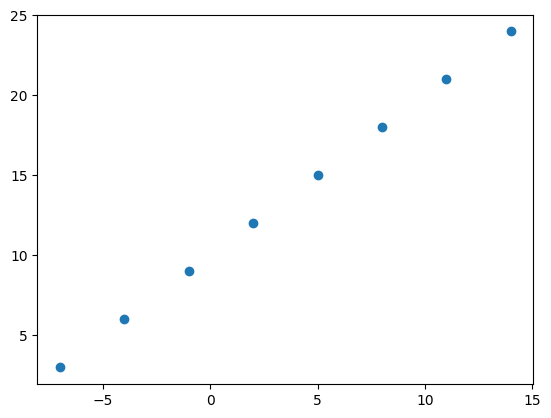

In [50]:
#Supervised
import matplotlib.pyplot as plt

X = np.array([-7.0, -4.0, -1, 2., 5, 8, 11., 14]);
y = np.array([3.0, 6.0, 9., 12., 15., 18., 21., 24.]);
X = tf.constant(X)
y=tf.constant(y)
plt.scatter(X,y)
# y ~= X+10

In [51]:
house_info = tf.constant(["bedroom", "bathroom", "garage"]);
house_price = tf.constant([937000]);
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([937000], dtype=int32)>)

In [52]:
input_dim = X[0].shape
output_dim = y[0].shape
#now modeling
tf.random.set_seed(108)

model = tf.keras.Sequential([
      tf.keras.layers.Dense(50, input_shape=[1], name="input_layer"),
      tf.keras.layers.Dense(30, name="hidden_layer"),
      tf.keras.layers.Dense(10, name="hidden_layer_2"),
       tf.keras.layers.Dense(1, name="output_layer")
]);

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

history = model.fit(X,y, epochs=50, verbose=0);
print(model.predict(tf.constant([17.], dtype=tf.float32))) # Fixed: wrapped 17. in a tf.constant tensor
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
[[29.062067]]


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,855 (22.88 KB)

 Trainable params: 1,951 (7.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,904 (15.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


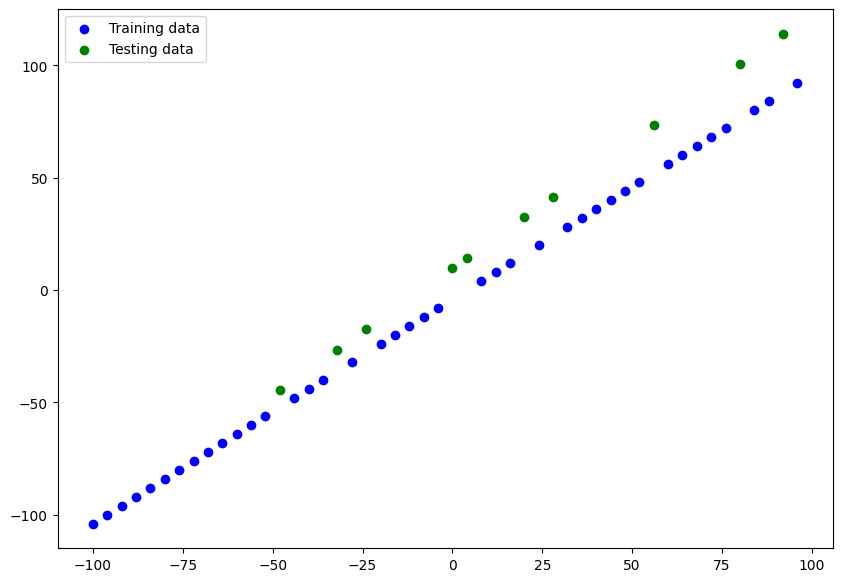

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 16.1421 - mae: 16.1421


(None, [16.142101287841797, 16.142101287841797])

In [53]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X = tf.range(-100, 100, 4)
y = X - 4
X_np = X.numpy()
y_np = y.numpy()

X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)
y_pred = model.predict(X_test)

def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    """
    Plots training data, test data, and optionally predictions.
    """
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", label="Training data")
    plt.scatter(test_data, test_labels, c="g", label="Testing data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", label="Predictions")
    plt.legend()
    plt.show()

plot_predictions(X_train, y_train, X_test, y_pred), model.evaluate(X_test, y_test)

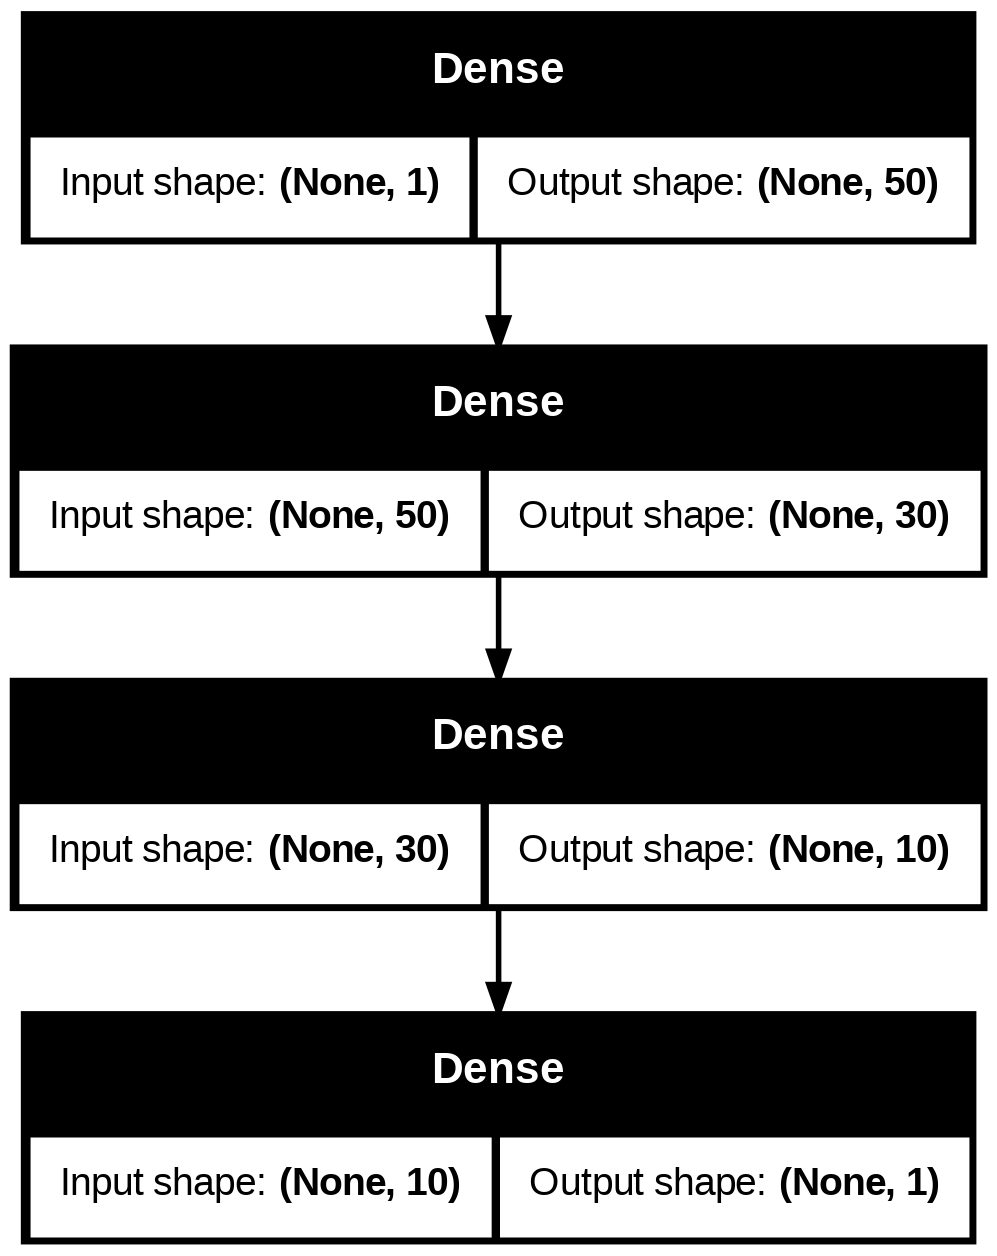

In [54]:
#Visualizing the layers of the NN
from tensorflow.keras.utils import plot_model
plot_model(model=model, show_shapes=True)

In [55]:
# Metrics / Losses
mae = tf.metrics.mae(y_test, y_pred);
mse = tf.metrics.mse(y_test, y_pred);
hubr = tf.metrics.huber(y_test, y_pred); #combination of mae, mse
mae, mse, hubr

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 7.392147, 21.264023, 16.462223, 24.465233,  9.526278, 26.065834,
        14.328088, 13.794553, 17.529293, 10.593346], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 54.643837, 452.15866 , 271.0048  , 598.5476  ,  90.74996 ,
        679.42773 , 205.2941  , 190.28969 , 307.27612 , 112.21897 ],
       dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 6.892147, 20.764023, 15.962223, 23.965233,  9.026278, 25.565834,
        13.828088, 13.294553, 17.029293, 10.093346], dtype=float32)>)

In [56]:
# saving a model
# Two main format: saveModel, HDF5
# model.save('model.h5')
# loaded = tf.keras.models.load_model('fileName')

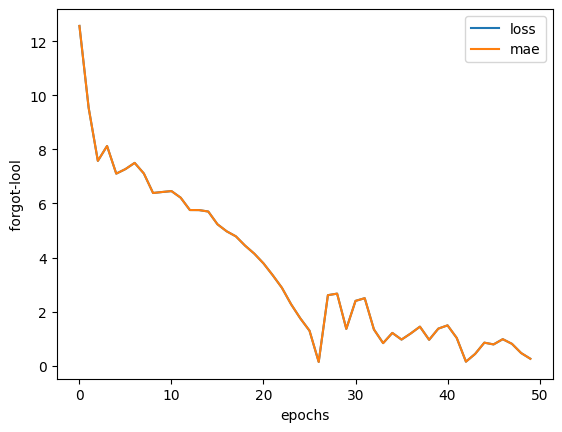

In [57]:
#history = model.fit();
import pandas as pd;
pd.DataFrame(history.history).plot()
plt.ylabel(' forgot-lool ')
plt.xlabel('epochs')
plt.show()

In [58]:
# Standarzing / Encoding, Unified Column Transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

data = {
    'numerical_feature_1': np.random.rand(10) * 100,
    'numerical_feature_2': np.random.randint(1, 10, 10),
    'categorical_feature_1': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'B', 'A', 'C'],
    'categorical_feature_2': ['Red', 'Blue', 'Green', 'Red', 'Blue', 'Green', 'Red', 'Blue', 'Green', 'Red']
}
df = pd.DataFrame(data)

numerical_features = ['numerical_feature_1', 'numerical_feature_2']
categorical_features = ['categorical_feature_1', 'categorical_feature_2']

# Create a column transformer that applies StandardScaler and OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any, without transforming
)

print("Unified transformer created using ColumnTransformer:")
print(preprocessor)

Unified transformer created using ColumnTransformer:
ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['numerical_feature_1',
                                  'numerical_feature_2']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['categorical_feature_1',
                                  'categorical_feature_2'])])


# Activation func:
Sigmoid, Relu, Leaky-Relu, Hyperbolic Tan, Softmax, Linear(none)

# CallBacks:
are extra functionality u can addd to your models to be performed during training ex: **EarlyStopping callback**



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Axes: >

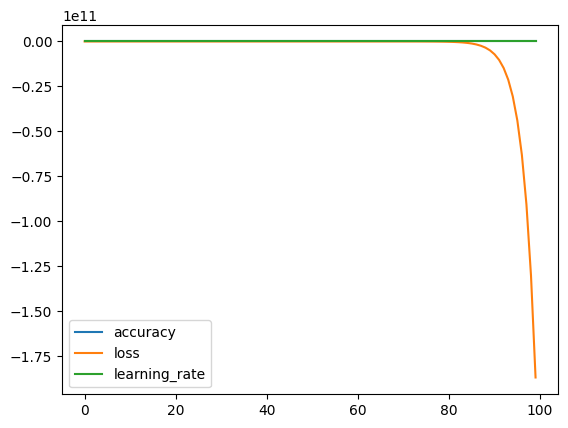

In [60]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu, input_shape=[1]),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

model_3.compile(loss=tf.keras.losses.BinaryCrossentropy,
                optimizer="Adam",
                metrics = ['accuracy']);

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10 ** (epoch/20))

history_3 = model_3.fit(X_train, y_train, epochs=100,
                        callbacks=[ lr_scheduler ], verbose=0);

pd.DataFrame(history_3.history).plot()


# Resource to visualize: made with ml(GitHub),
# https://cs231.github.io/neural-networks-case-study
# tf.round(), for rounding values

# CNN: https://poloclub.github.io/cnn-explainer/

In [61]:
import tensorflow as tf

cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10, #no. of kernel
                           kernel_size= 5, #pix per kernel matrix(smol for smol features, LfL)
                           strides=(1,1), #how much px kernel should move each time
                           padding='valid',# if img size not as per kernel add this, or 'same'(adds zeroes as padding)
                           activation='relu'),

    tf.keras.layers.MaxPool2D(pool_size=(2,2)), #regularization layer
    tf.keras.layers.Activation(activation='relu'),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, strides=(1,1), padding='valid', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

cnn.compile(loss=tf.keras.losses.BinaryCrossentropy,
            optimizer=tf.keras.optimizers.Adam(),
            metrics=['accuracy']);

In [ ]:
""" For Image Augmentation: Use this to reduce overfitting """
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Initialize with augmentation parameters
datagen = ImageDataGenerator(
    rescale=1./255,           # Normalise pixel values to [0, 1]
    rotation_range=40,        # Randomly rotate images
    width_shift_range=0.2,    # Randomly shift horizontally
    height_shift_range=0.2,   # Randomly shift vertically
    horizontal_flip=True,      # Flip images horizontally
    fill_mode='nearest'       # How to fill new pixels after rotation/shift
)

train_generator = datagen.flow_from_directory(
    'path/to/train_data/',    # Directory with subfolders for each class
    target_size=(150, 150),   # Resize all images to 150x150
    batch_size=32,            # Number of images per batch
    class_mode='binary'       # Use 'categorical' for >2 classes
)

history = model.fit(
    train_generator,
    steps_per_epoch=8,       # (Total training images / batch_size)
    epochs=15,
    #validation_data=validation_generator, # Optional: flow from a validation dir
    validation_steps=4,      # (Total validation images / batch_size)
    verbose=1
)



In [ ]:
# If you wanted to, you could really turn this into a helper function to load in with a helper.py script...
import matplotlib.pyplot as plt

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

# TRANSFER LEARNING
from TensorflowHub: https://tfhub.dev/

In [ ]:
# Create tensorboard callback (functionized because need to create a new one for each model)
import datetime
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

resnet_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/4"

efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

def create_model(model_url, num_classes=10):
  """Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url (str): A TensorFlow Hub feature extraction URL.
    num_classes (int): Number of output neurons in output layer,
      should be equal to number of target classes, default 10.

  Returns:
    An uncompiled Keras Sequential model with model_url as feature
    extractor layer and Dense output layer with num_classes outputs.
  """
  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable=False, # freeze the underlying patterns
                                           name='feature_extraction_layer',
                                           input_shape=IMAGE_SHAPE+(3,)) # define the input image shape

  # Create our own model
  model = tf.keras.Sequential([
    feature_extractor_layer, # use the feature extraction layer as the base
    layers.Dense(num_classes, activation='softmax', name='output_layer') # create our own output layer
  ])

  return model

# Create model
resnet_model = create_model(resnet_url, num_classes=train_data_10_percent.num_classes)
resnet_model.compile(loss='categorical_crossentropy',
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=['accuracy'])
resnet_history = resnet_model.fit(train_data_10_percent,
                                  epochs=5,
                                  steps_per_epoch=len(train_data_10_percent),
                                  validation_data=test_data,
                                  validation_steps=len(test_data),
                                  # Add TensorBoard callback to model (callbacks parameter takes a list)
                                  callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub", # save experiment logs here
                                                                         experiment_name="resnet50V2")]) # name of log files

# Create model
efficientnet_model = create_model(model_url=efficientnet_url, # use EfficientNetB0 TensorFlow Hub URL
                                  num_classes=train_data_10_percent.num_classes)
efficientnet_model.compile(loss='categorical_crossentropy',
                           optimizer=tf.keras.optimizers.Adam(),
                           metrics=['accuracy'])
efficientnet_history = efficientnet_model.fit(train_data_10_percent, # only use 10% of training data
                                              epochs=5, # train for 5 epochs
                                              steps_per_epoch=len(train_data_10_percent),
                                              validation_data=test_data,
                                              validation_steps=len(test_data),
                                              callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                                                                     # Track logs under different experiment name
                                                                                     experiment_name="efficientnetB0")])

